In [6]:
# Final pipeline running on grand arrays created for each experiment
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from matplotlib.collections import LineCollection
import pandas as pd
from scipy.ndimage import uniform_filter1d
from skimage.filters import apply_hysteresis_threshold
from scipy.ndimage import gaussian_filter1d
from IPython.display import HTML
from cleaning_pipeline_functions import *

In [3]:
# loading data - the grand array
data = np.load('/home/hck03/Documents/MS_thesis/tracking_output/1c_4n_faulty/Clip0070_1C_4N_E3_8/data/grand_array.npy')
no_of_fishes = data.shape[0]
no_of_frames = data.shape[1]
# data.shape

In [4]:
# preliminary processing
data[np.isinf(data)] = np.nan

vel_x = np.gradient(data[:,:,0], axis=1)
vel_y = np.gradient(data[:,:,1], axis=1)

vel = np.zeros((no_of_fishes, no_of_frames, 2))
vel[:, :, 0] = vel_x
vel[:, :, 1] = vel_y

speed = np.linalg.norm(vel, axis=2, ord=2)

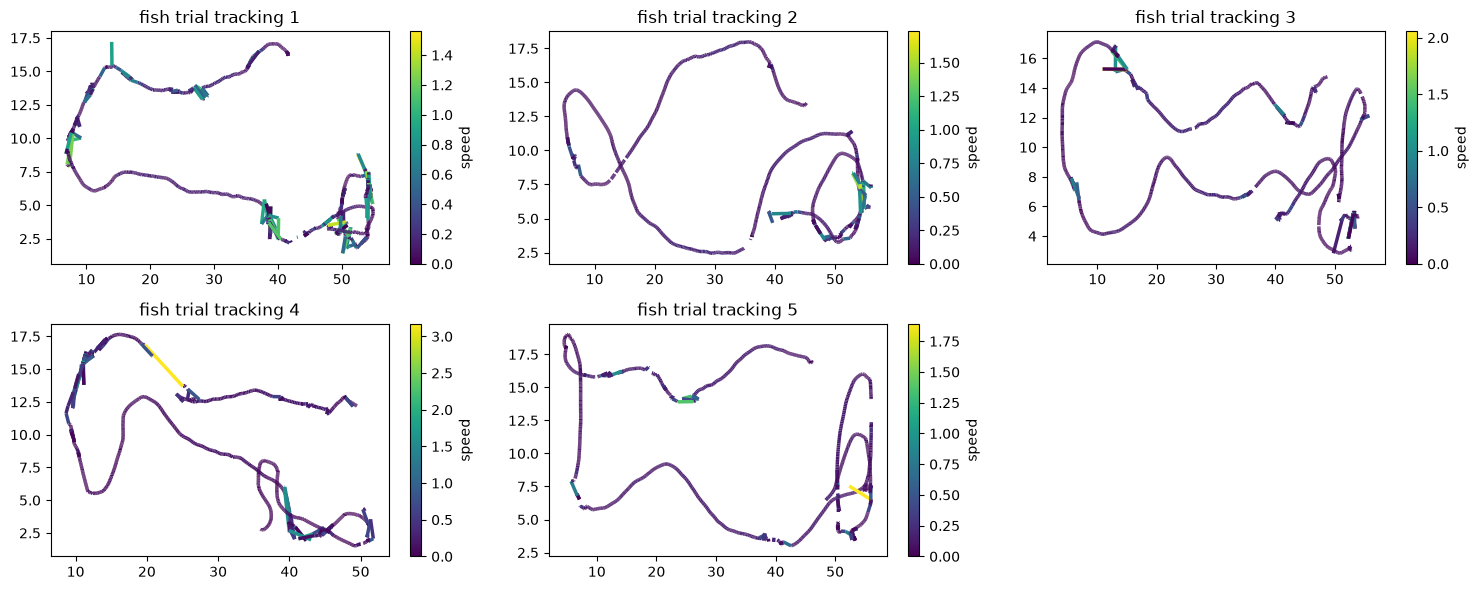

In [5]:
fig, ax = plt.subplots(2, 3, figsize=(15, 6))
flat_axes = ax.flatten()

fig.delaxes(flat_axes[5])

for i in range(no_of_fishes):
    current_axis = flat_axes[i]
    time_steps = no_of_frames
    fish_x = data[i, :, 0]
    fish_y = data[i, :, 1]
    # fish_speeds = speed[i, :]
    speedy_trail(fish_x, fish_y, ax=current_axis, label=f"Fish {i+1}")
    current_axis.set_title(f"fish trial tracking {i+1}")

plt.tight_layout()
plt.show() 

In [6]:
# # Acquiring scores
# E_scores_array = np.zeros((no_of_fishes, no_of_frames))

# for i in range(no_of_fishes):
#     x = data[i, :, 0]
#     y = data[i, :, 0]
#     E_scores_array[i, :] = filter(x, y, k=7)

In [7]:
# # Determining thresholds
# fig, ax = plt.subplots(2, 3, figsize=(15, 6))
# flat_axes = ax.flatten()

# fig.delaxes(flat_axes[5])

# highs = [0.4, 0.4, 0.5, 0.5, 0.5]
# lows = [0.1, 0.1, 0.1, 0.1, 0.1]

# for i in range(no_of_fishes):
#     E_scores_i = E_scores_array[i, :]
#     flat_axes[i].plot(range(len(E_scores_i)), E_scores_i)
#     flat_axes[i].axhline(y=highs[i], color='red', linestyle='--')
#     flat_axes[i].axhline(y=lows[i], color='green', linestyle='--')
#     flat_axes[i].set_title(f"Fish {i+1}")
#     flat_axes[i].set_xlabel("Frames")
#     flat_axes[i].set_ylabel("E score")

# plt.tight_layout()
# plt.show()

In [8]:
# # plotting corrected trajectories
# fig, ax = plt.subplots(2, 3, figsize=(15, 6))
# flat_axes = ax.flatten()

# fig.delaxes(flat_axes[5])

# E_scores_array[np.isnan(E_scores_array)] = 0
# data_clean = data.copy()

# for i in range(no_of_fishes):
#     fish_E = E_scores_array[i, :]

#     hyst_mask = apply_hysteresis_threshold(fish_E, lows[i], highs[i])
#     # print(hyst_mask.sum())

#     x_clean = data_clean[i, :, 0]
#     y_clean = data_clean[i, :, 1]

#     x_clean[hyst_mask] = np.nan
#     y_clean[hyst_mask] = np.nan

#     data_clean[i, :, 0] = x_clean
#     data_clean[i, :, 1] = y_clean

#     flat_axes[i].plot(data[i, :, 0], data[i, :, 1], alpha=0.5)
#     flat_axes[i].plot(x_clean, y_clean, color='black')
#     flat_axes[i].set_title(f"Fish {i+1}")
# plt.tight_layout()
# plt.show()

In [9]:
# # blanketting_old
# fig, ax = plt.subplots(2, 3, figsize=(15, 6))
# flat_axes = ax.flatten()

# fig.delaxes(flat_axes[5])

# data_blanket = data_clean.copy()
# k = 30
# r = 0.3

# for i in range(no_of_fishes):
#     x = data[i, :, 0]
#     y = data[i, :, 1]

#     x_clean = data[i, :, 0]
#     y_clean = data[i, :, 1]

#     x_blanket = data_blanket[i, :, 0]
#     y_blanket = data_blanket[i, :, 1]

#     med_filtered_x = pd.Series(x).rolling(window=k, min_periods=1, center=True).median().to_numpy()
#     med_filtered_y = pd.Series(y).rolling(window=k, min_periods=1, center=True).median().to_numpy()
#     # med_filtered_x = pd.Series(x_anchors).interpolate(method='pchip').to_numpy()
#     # med_filtered_y = pd.Series(y_anchors).interpolate(method='pchip').to_numpy()

#     center_line = np.vstack((med_filtered_x, med_filtered_y))
#     clean_pos = np.vstack((x_clean, y_clean))

#     dist_from_cl = clean_pos - center_line
#     dist_from_cl = np.linalg.norm(dist_from_cl, axis=0, ord=2)

#     out_of_blanket_mask = (dist_from_cl >= r)

#     fault_x = x_blanket[out_of_blanket_mask]
#     fault_y = y_blanket[out_of_blanket_mask]

#     x_blanket[out_of_blanket_mask] = np.nan
#     y_blanket[out_of_blanket_mask] = np.nan

#     data_blanket[i, :, 0] = x_blanket
#     data_blanket[i, :, 1] = y_blanket
    
#     flat_axes[i].plot(x, y, alpha=0.5)
#     flat_axes[i].plot(med_filtered_x, med_filtered_y, 'g--', alpha=0.8)
#     flat_axes[i].plot(x_clean, y_clean, color='red', alpha=0.8)
#     flat_axes[i].plot(x_blanket, y_blanket, color='black')
#     flat_axes[i].set_title(f"Fish {i+1}")
# plt.tight_layout()
# plt.show()

0.2
Fraction of track retained for fish 1: 0.767
0.2
Fraction of track retained for fish 2: 0.905
0.2
Fraction of track retained for fish 3: 0.9
0.2
Fraction of track retained for fish 4: 0.852
0.2
Fraction of track retained for fish 5: 0.899


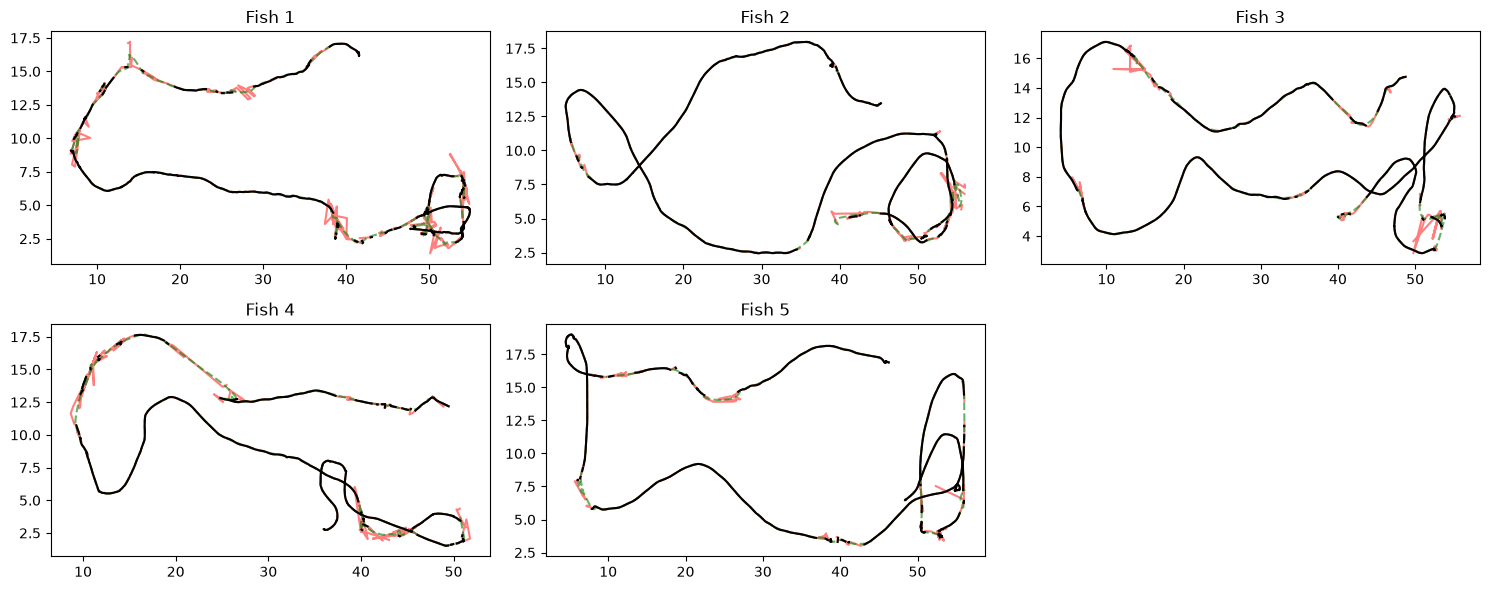

In [10]:
# Blanketting alone suffices 
fig, ax = plt.subplots(2, 3, figsize=(15, 6))
flat_axes = ax.flatten()

fig.delaxes(flat_axes[5])

data_blanket = data.copy()

for i in range(no_of_fishes):
    x = data[i, :, 0]
    y = data[i, :, 1]
    
    x_med_corrected, y_med_corrected, x_med_smooth, y_med_smooth, frac = blanket(x, y, method="savgol", r=0.2)
    data_blanket[i, :, 0] = x_med_corrected
    data_blanket[i, :, 1] = y_med_corrected
    
    flat_axes[i].plot(x, y, 'r', alpha=0.5)
    flat_axes[i].plot(x_med_smooth, y_med_smooth, 'g--', alpha=0.6)
    flat_axes[i].plot(x_med_corrected, y_med_corrected, 'k')

    # flat_axes[i].text(0.73, 0.8, f"frac_retained=\n{round(frac,3)}", transform=flat_axes[i].transAxes)
    flat_axes[i].set_title(f"Fish {i+1}")
    print(f"Fraction of track retained for fish {i+1}:", round(frac,3))

plt.tight_layout()
plt.show()


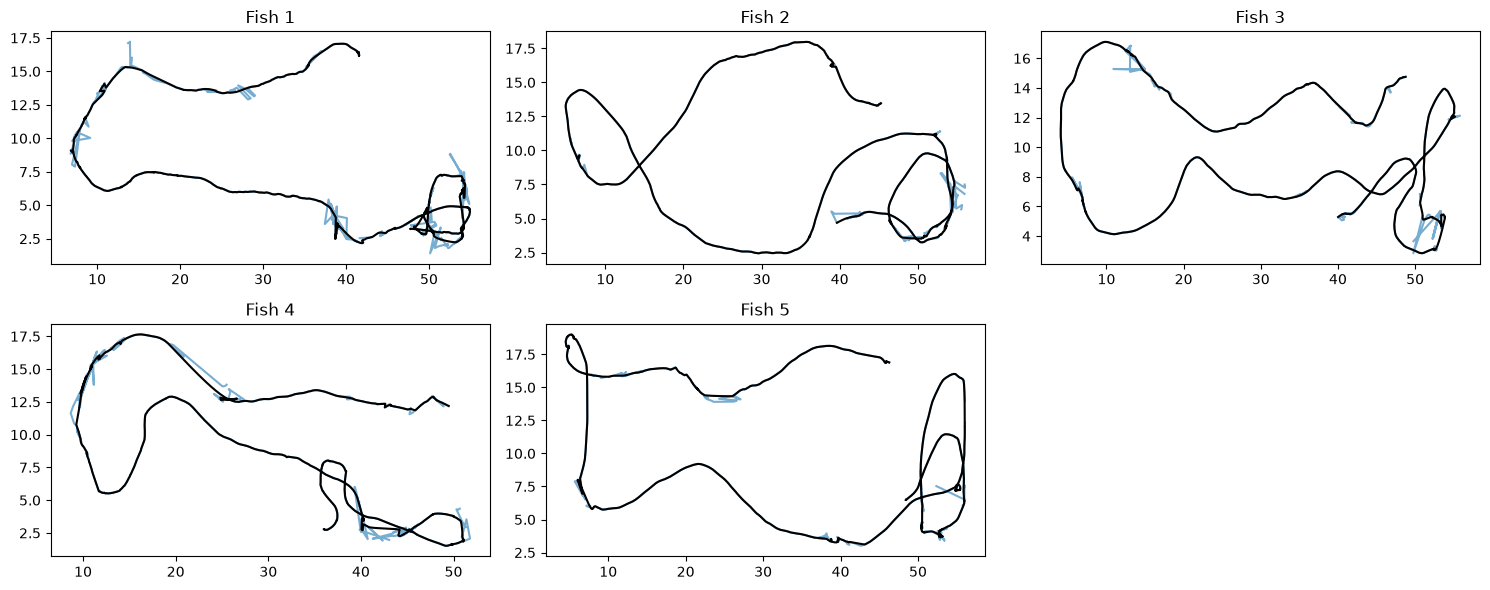

In [11]:
# interpolating
fig, ax = plt.subplots(2, 3, figsize=(15, 6))
flat_axes = ax.flatten()

fig.delaxes(flat_axes[5])

data_final = np.zeros(data.shape)

for i in range(no_of_fishes):
    x = data[i, :, 0]
    y = data[i, :, 1]
    
    x_blanket_0 = data_blanket[i, :, 0]
    y_blanket_0 = data_blanket[i, :, 1]

    x_interp = pd.Series(x_blanket_0).interpolate(method='pchip').to_numpy()
    y_interp = pd.Series(y_blanket_0).interpolate(method='pchip').to_numpy()

    data_final[i, :, 0] = x_interp
    data_final[i, :, 1] = y_interp

    flat_axes[i].plot(x, y, alpha=0.6)
    flat_axes[i].plot(x_interp, y_interp, color='black')
    flat_axes[i].set_title(f"Fish {i+1}")
plt.tight_layout()
plt.show()

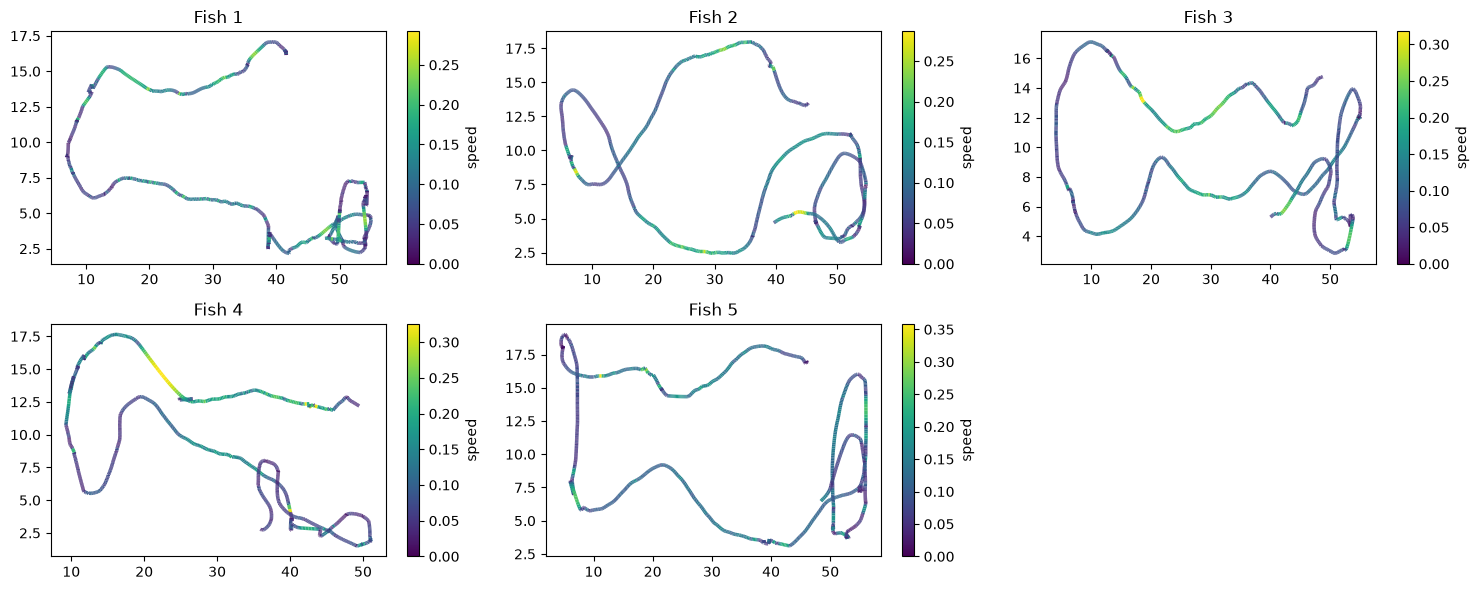

In [12]:
# interpolated plots speedy trails
fig, ax = plt.subplots(2, 3, figsize=(15, 6))
flat_axes = ax.flatten()

fig.delaxes(flat_axes[5])

for i in range(no_of_fishes):
    x_intp_speed = data_final[i, :, 0]
    y_intp_speed = data_final[i, :, 1]

    speedy_trail(x_intp_speed, y_intp_speed, flat_axes[i])
    # flat_axes[i].plot(x_interp, y_interp, color='black')
    flat_axes[i].set_title(f"Fish {i+1}")
plt.tight_layout()
plt.show()

In [13]:
# lets check for angle issues
x_temp, y_temp = data_final[3,:,0].copy(), data_final[3,:,1].copy()
positions = np.vstack((x_temp,y_temp))
positions = positions.T
positions[np.isinf(positions)] = np.nan

vec = np.diff(positions, axis=0)
dot_prod_new = np.sum(vec[1:,:]*vec[:-1,:], axis=1)
denominator = (np.linalg.norm(vec[1:, :], axis=1)*np.linalg.norm(vec[:-1,:], axis=1))
safe_mask = (denominator > 0)
cos_theta_new = np.zeros(dot_prod_new.shape[0])
cos_theta_new[safe_mask] = dot_prod_new[safe_mask]/denominator[safe_mask]
cos_theta_new = np.clip(cos_theta_new, -1.0, 1.0)

angle_threshold = -0.0



angle_spikes_mask = (cos_theta_new < angle_threshold)
angle_spikes_new = np.arange(len(cos_theta_new))[angle_spikes_mask]

In [14]:
angle_spikes_new

array([  48,   50,   81,   82,   93,   94,   97,   98,  198,  220,  297,
        298,  317,  318,  319,  320,  322,  331,  346,  350,  382,  394,
        415,  416,  505,  511,  588,  998,  999, 1042, 1043, 1045, 1059,
       1250, 1251, 1252, 1253, 1309, 1310, 1311, 1312, 1359, 1360, 1361,
       1376, 1377, 1385, 1386, 1425, 1426, 1431, 1432, 1443, 1444, 1446,
       1448, 1601, 1602, 1631, 1633, 1634, 1635, 1636, 1637, 1705, 1728,
       1730, 1836, 1870, 1871, 1872])

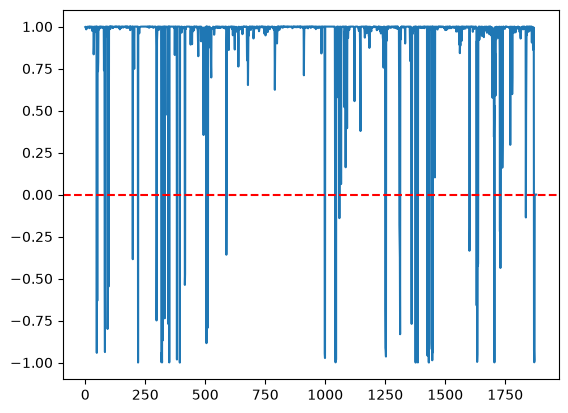

In [15]:

plt.plot(range(len(cos_theta_new)), cos_theta_new)
plt.axhline(y=angle_threshold, color='red', linestyle="--")

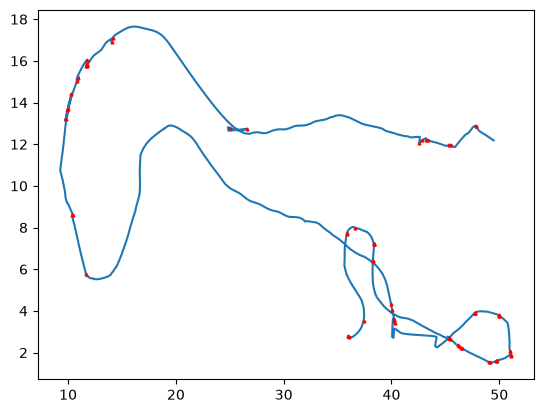

In [16]:


plt.plot(x_temp, y_temp)

for i in angle_spikes_new:
    plt.plot(x_temp[i], y_temp[i], color='red', marker='^', markersize=2)

plt.show()

In [17]:
x_temp[angle_spikes_new]

array([47.81159592, 47.81438828, 45.4819603 , 45.37958145, 43.35154724,
       43.21397781, 42.83354187, 42.58057022, 25.02555275, 26.59936523,
       14.1480999 , 14.03651237, 11.77953148, 11.7342205 , 11.794487  ,
       11.74692822, 11.70419884, 11.76716423, 10.81014824, 10.9578886 ,
        9.76194   , 10.31248379,  9.95330524,  9.94291306, 10.43292618,
       10.37559319, 11.67041683, 39.95452881, 40.04821014, 40.27065277,
       40.27550125, 40.27647018, 40.29601288, 47.74692535, 47.76218796,
       47.74505615, 47.76422119, 50.00003815, 50.00961685, 49.98849869,
       49.99689102, 51.09213257, 51.04335785, 51.00509262, 49.81568146,
       49.73517227, 49.10555649, 49.03364182, 46.52664948, 46.43126678,
       46.24330521, 46.14018631, 45.43482208, 45.37926483, 45.30641174,
       45.33590317, 38.27695084, 38.281353  , 38.40842819, 38.40323639,
       38.3883667 , 38.39552689, 38.38188553, 38.36911011, 36.63261795,
       35.85632706, 35.86600876, 37.42001343, 36.02260208, 35.97

In [18]:
positions = np.vstack((x_temp,y_temp))
positions = positions.T
positions[np.isinf(positions)] = np.nan

vec = np.diff(positions, axis=0)

In [19]:
np.array([1,2])*np.array([1,2])

array([1, 4])

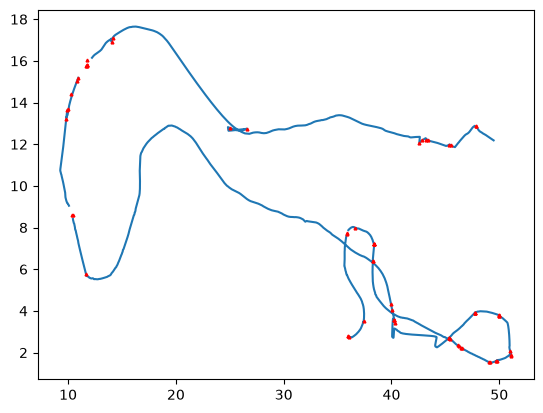

In [ ]:
# time to clean these spikes
## we will find pairs where the first spike encountered is ahead of the next spike encountered
# %matplotlib widget
x_temp_new = x_temp.copy()
y_temp_new = y_temp.copy() 
no_of_frames_between_list = np.diff(angle_spikes_new)
for i in range(len(angle_spikes_new)-1):
    first_spike = angle_spikes_new[i]
    next_spike = angle_spikes_new[i+1]
    no_of_frames_between = (next_spike - first_spike) + 1
    # no_of_frames_between_list.append(no_of_frames_between)
    incomming_heading = vec[first_spike-1]
    outgoing_heading = vec[next_spike-1]
    dot_prod = np.sum(incomming_heading*outgoing_heading, )
    denom = np.linalg.norm(incomming_heading, ord=2)*np.linalg.norm(outgoing_heading, ord=2)
    cos_theta = dot_prod/denom
    # print(no_of_frames_between)
    if cos_theta < -0.5 and no_of_frames_between < np.percentile(no_of_frames_between_list, 75):
        pad_size = 3
        x_temp_new[first_spike-pad_size:next_spike+1+pad_size] = np.nan
        y_temp_new[first_spike-pad_size:next_spike+1+pad_size] = np.nan

# plt.hist(no_of_frames_between_list)
plt.plot(x_temp_new, y_temp_new)
for i in angle_spikes_new:
    plt.plot(x_temp[i], y_temp[i], color='red', marker='^', markersize=2)


In [52]:
no_of_frames_between_list

array([  2,  31,   1,  11,   1,   3,   1, 100,  22,  77,   1,  19,   1,
         1,   1,   2,   9,  15,   4,  32,  12,  21,   1,  89,   6,  77,
       410,   1,  43,   1,   2,  14, 191,   1,   1,   1,  56,   1,   1,
         1,  47,   1,   1,  15,   1,   8,   1,  39,   1,   5,   1,  11,
         1,   2,   2, 153,   1,  29,   2,   1,   1,   1,   1,  68,  23,
         2, 106,  34,   1,   1])

In [44]:
# plt.hist(no_of_frames_between_list, bins=70)
np.percentile(no_of_frames_between_list, 75)

np.float64(23.75)

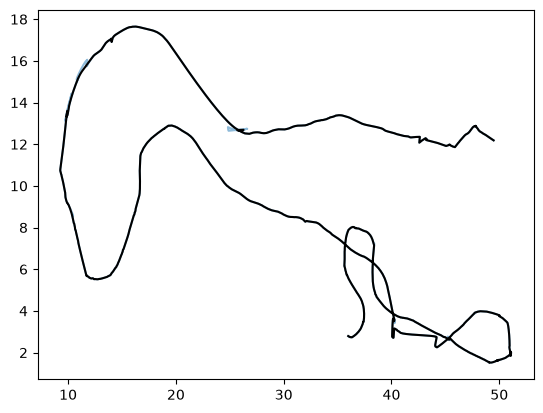

In [48]:
x_interp_new = pd.Series(x_temp_new).interpolate(method='pchip').to_numpy()
y_interp_new = pd.Series(y_temp_new).interpolate(method='pchip').to_numpy()

plt.close()
plt.plot(x_temp, y_temp, alpha=0.5)
plt.plot(x_interp_new, y_interp_new, 'k')
plt.show()


In [8]:
import numpy as np
data_loaded = np.load('/home/hck03/Documents/MS_thesis/tracking_output/1c_4n_faulty/Clip0083_1C_4N_E8_10/data/clean_tracks.npy')
data_loaded[np.isinf(data_loaded)] = np.nan

In [9]:
# entirely written by gemini...overlays track over the video
import cv2
import numpy as np

video_path = '/run/media/hck03/Vivek/conditioning_experiments_cassandre_videos/Slow_motion_1C_4N/4nov/Clip0083_1C_4N_E8_10.mp4'
cap = cv2.VideoCapture(video_path)

# Get video properties for the writer
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
fps = cap.get(cv2.CAP_PROP_FPS)


tracking_pixels = data_loaded[2, :, :]*(1/ 0.03720)
# Initialize the OpenCV Video Writer
fourcc = cv2.VideoWriter_fourcc(*'mp4v') # Codec for .mp4
out = cv2.VideoWriter('tracking_output_raw_id2_83.mp4', fourcc, fps, (width, height))

frame_idx = 0
# Assuming tracking_pixels is your corrected Nx2 array
while cap.isOpened() and frame_idx < len(tracking_pixels):
    ret, frame = cap.read()
    if not ret:
        break # End of video
        
    # Extract current pixel coordinates (must be integers for OpenCV drawing)
    # Using np.nan_to_num in case your data has NaN values from lost tracking
    x = int(np.nan_to_num(tracking_pixels[frame_idx, 0]))
    y = int(np.nan_to_num(tracking_pixels[frame_idx, 1]))
    
    # Draw a solid red circle on the frame at the fish's location
    # Colors in OpenCV are (B, G, R)
    cv2.circle(frame, (x, y), radius=4, color=(0, 0, 255), thickness=-1)
    
    # Optional: Draw the trailing path
    if frame_idx > 0:
        # Get valid coordinates up to the current frame
        path_pts = tracking_pixels[:frame_idx+1].astype(np.int32)
        # Reshape for polylines: needs shape (number_of_points, 1, 2)
        path_pts = path_pts.reshape((-1, 1, 2))
        cv2.polylines(frame, [path_pts], isClosed=False, color=(0, 0, 255), thickness=1)
    
    # Write the modified frame to the new video file
    out.write(frame)
    frame_idx += 1

# Release resources
cap.release()
out.release()

In [8]:
tracking_pixels_y.shape

(1816,)

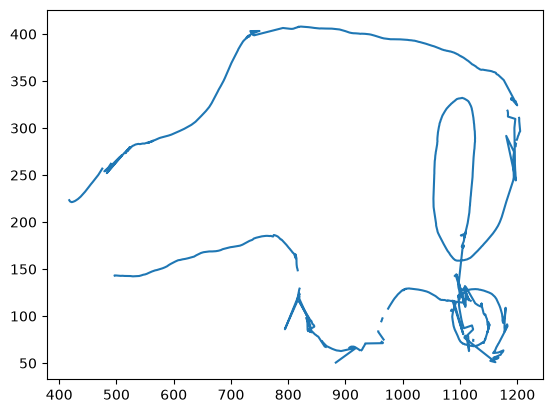

In [7]:
plt.plot(tracking_pixels_x, tracking_pixels_y)

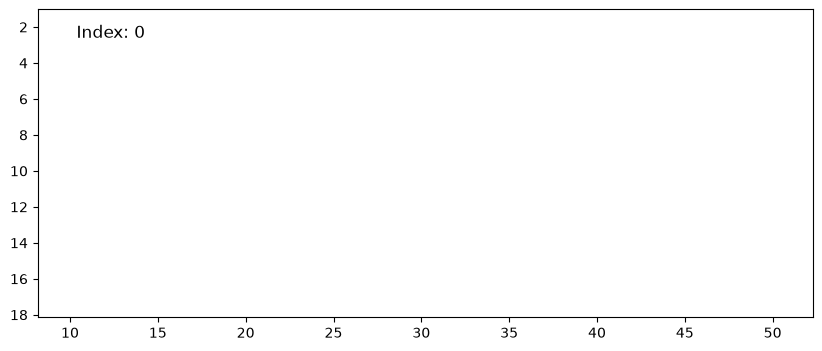

In [21]:
animate_trajectory(data[3, :, 0], data[3, :, 1], filename="Clip0070_1C_4N_E3_8_id3")

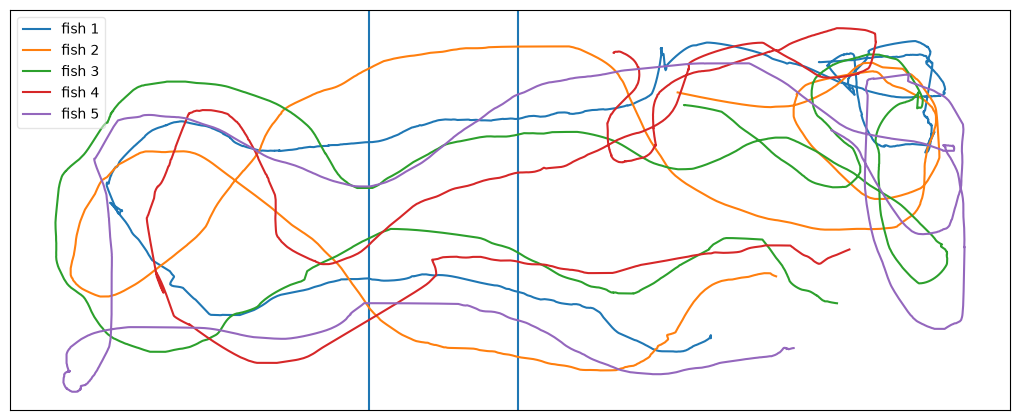

In [13]:
# grand plot 

length = 10
# aspect_x, aspect_y = 1380, 596
fig = plt.figure(figsize=(length,(length/(50/20))))
ax = fig.add_axes([0, 0, 1, 1])
# ax.axis('off')
xmin, xmax = 0, 50
ymin, ymax = 0, 50/(50/20)


ax.set_xticks([])
ax.set_yticks([])
mid_way = (np.nanmin(data_final[:,:,0]) + np.nanmax(data_final[:,:,0]))/2
ax.axvline(x=22)
ax.axvline(x=30.5)


for i in range(no_of_fishes):
    track = data_final[i, :, :]
    track_x = track[:,0]
    track_y = track[:,1]
    
    # ax.invert_xaxis()
    ax.plot(track_x, track_y, label = f"fish {i+1}")
ax.invert_yaxis()
# img = plt.imread('/home/hck03/Documents/MS_thesis/tracking_output/1c_4n_faulty/Clip0070_1C_4N_E3_8/average_Clip0070_1C_4N_E3_8.png')
# ax.imshow(img, extent=[xmin, xmax, ymin, ymax], aspect='auto', zorder=0)
ax.legend(loc = "upper left", framealpha = 0.5)


In [14]:
# def animate_trajectory_all(data, filename, colors, ax=None):
#     total_frames = data.shape[1]
#     no_fishes = data.shape[0]

#     # valid_data = data[np.isfinite(data)]
#     # print(valid_data.shape)
#     valid_x = data[:, :, 0]
#     valid_y = data[:, :, 1]

#     if ax is None:
#         fig = plt.figure(figsize=(length,(length/(50/20))))
#         ax = fig.add_axes([0, 0, 1, 1])
#         # ax.axis('off')
#         ax.set_xticks([])
#         ax.set_yticks([])
#         mid_way = (np.nanmin(valid_x) + np.nanmax(valid_x))/2
#         ax.axvline(x=mid_way-5)
#         ax.axvline(x=mid_way+5)
#     else:
#         fig = ax.get_figure()

#     ax.set_xlim(np.nanmin(valid_x)-0.5, np.nanmax(valid_x)+0.5)
#     ax.set_ylim(np.nanmin(valid_y)-0.5, np.nanmax(valid_y)+0.5)

#     frame_text = ax.text(0.05, 0.95, '', transform=ax.transAxes, fontsize=12, verticalalignment='top')
#     lines = [ax.plot([], [], color=colors[i], linewidth=2, label=f'Fish {i+1}')[0] for i in range(no_fishes)]

#     def update(frame):
#         for i in range(no_fishes):
#             current_x = valid_x[i,:frame+1]
#             current_y = valid_y[i,:frame+1]
#             lines[i].set_data(current_x, current_y)
#         frame_text.set_text(f'Index: {frame}')
#         return (*lines, frame_text)

#     ani = FuncAnimation(fig, update, frames=total_frames, interval=40, blit=False, repeat=False)
#     ani.save(f'{filename}.mp4', writer='ffmpeg', fps=25)

# colors = ['#2563EB', '#10B981', '#F59E0B', '#EF4444', '#8B5CF6']

# animate_trajectory_all(data_final, 'Clip0070_1C_4N_E3_8', colors)

In [15]:
# img = plt.imread('/home/hck03/Documents/MS_thesis/tracking_output/1c_4n_faulty/Clip0070_1C_4N_E3_8/average_Clip0070_1C_4N_E3_8.png')

# fig = plt.figure(figsize=(10,(10/(50/20))))
# ax = fig.add_axes([0, 0, 1, 1])
# xmin, xmax = 0, 50
# ymin, ymax = 0, 50/(50/20)

# ax.imshow(img, extent=[xmin, xmax, ymin, ymax], aspect='auto', zorder=0)
# ax.set_xticks([])
# ax.set_yticks([])
# ax.set_xlim(xmin, xmax)
# ax.set_ylim(ymin, ymax)
# ax.axvline(x=22)
# ax.axvline(x=30.5)
# plt.show()

In [ ]:
# velocity of interpolated data
vel_x_clean = np.gradient(data_final[:,:,0], axis=1)
vel_y_clean = np.gradient(data_final[:,:,1], axis=1)

vel_clean = np.zeros((no_of_fishes, no_of_frames, 2))
vel_clean[:, :, 0] = vel_x_clean
vel_clean[:, :, 1] = vel_y_clean

In [30]:
# Let's check correlations
# def xcorr_new(vx_i, vx_j, max_tm):
#     tau_vals = np.arange(-max_tm, max_tm, 1)
#     C_ij = np.zeros(len(tau_vals))

#     for k in range(len(tau_vals)):
#         tau = tau_vals[k]
#         if tau > 0:
#             val = vx_i[:-tau]*vx_j[tau:]
#         elif tau < 0:
#             val = vx_i[-tau:]*vx_j[:tau]
#         else:
#             val = vx_i*vx_j
#         C_ij[k] = np.nanmean(val)
#     return C_ij, tau_vals

def xcorr_new(vx_i, vx_j, max_tm):
    tau_vals = np.arange(-max_tm, max_tm, 1)
    C_ij = np.zeros(len(tau_vals))

    for k in range(len(tau_vals)):
        tau = tau_vals[k]
        if tau > 0:
            vi_overlap = vx_i[:-tau]
            vj_overlap = vx_j[tau:]
        elif tau < 0:
            vi_overlap = vx_i[-tau:]
            vj_overlap = vx_j[:tau]
        else:
            vi_overlap = vx_i
            vj_overlap = vx_j
            
        # Calculate the covariance of the overlap
        covariance = np.nanmean(vi_overlap * vj_overlap)
        
        # Calculate the variances of the overlaps
        var_i = np.nanmean(vi_overlap**2)
        var_j = np.nanmean(vj_overlap**2)
        
        # Normalize to bound between -1 and 1
        denominator = np.sqrt(var_i * var_j)
        
        if denominator == 0 or np.isnan(denominator):
            C_ij[k] = np.nan
        else:
            C_ij[k] = covariance / denominator
            
    return C_ij, tau_vals

# When combining X and Y, average them so the max remains 1:
# C_ij = (C_ij_x + C_ij_y) / 2.0

max_tm = 20

grand_C_raw = np.zeros((no_of_fishes, 2*max_tm, no_of_fishes))
lag_array_raw = np.zeros((no_of_fishes, no_of_fishes))

grand_C_clean = np.zeros((no_of_fishes, 2*max_tm, no_of_fishes))
lag_array_clean = np.zeros((no_of_fishes, no_of_fishes))

c_min = 0.5
agents_i_raw = []
agents_j_raw = []
wghts_raw = []

agents_i_clean = []
agents_j_clean = []
wghts_clean = []

for i in range(no_of_fishes):
    vx_i = vel[i, :, 0]
    vy_i = vel[i, :, 1]
    vx_i_clean = vel_clean[i, :, 0]
    vy_i_clean = vel_clean[i, :, 1]

    for j in range(no_of_fishes):
        vx_j = vel[j, :, 0]
        vy_j = vel[j, :, 1]
        vx_j_clean = vel_clean[j, :, 0]
        vy_j_clean = vel_clean[j, :, 1]
        # raw
        C_ij_x,_ = xcorr_new(vx_i, vx_j, max_tm)
        C_ij_y,tau_vals = xcorr_new(vy_i, vy_j, max_tm)
        C_ij = C_ij_x + C_ij_y
        tau_prime_raw = tau_vals[np.argmax(C_ij)]
        # clean
        C_ij_x_c,_ = xcorr_new(vx_i_clean, vx_j_clean, max_tm)
        C_ij_y_c,tau_vals_c = xcorr_new(vy_i_clean, vy_j_clean, max_tm)
        C_ij_c = C_ij_x_c + C_ij_y_c
        tau_prime_clean = tau_vals_c[np.argmax(C_ij_c)]

        if np.max(C_ij)>=c_min and tau_prime_raw < 0:
            lag_array_raw[i, j] = tau_prime_raw
            lag_array_raw[j, i] = -1*tau_prime_raw
            agents_i_raw.append(i)
            agents_j_raw.append(j)
            wghts_raw.append(np.abs(tau_prime_raw))

        if np.max(C_ij_c)>=0 and tau_prime_clean < 0:
            lag_array_clean[i, j] = tau_prime_clean
            lag_array_clean[j, i] = -1*tau_prime_clean
            agents_i_clean.append(i)
            agents_j_clean.append(j)
            wghts_clean.append(np.abs(tau_prime_clean))
        
        grand_C_raw[i, :, j] = C_ij
        grand_C_clean[i, :, j] = C_ij_c

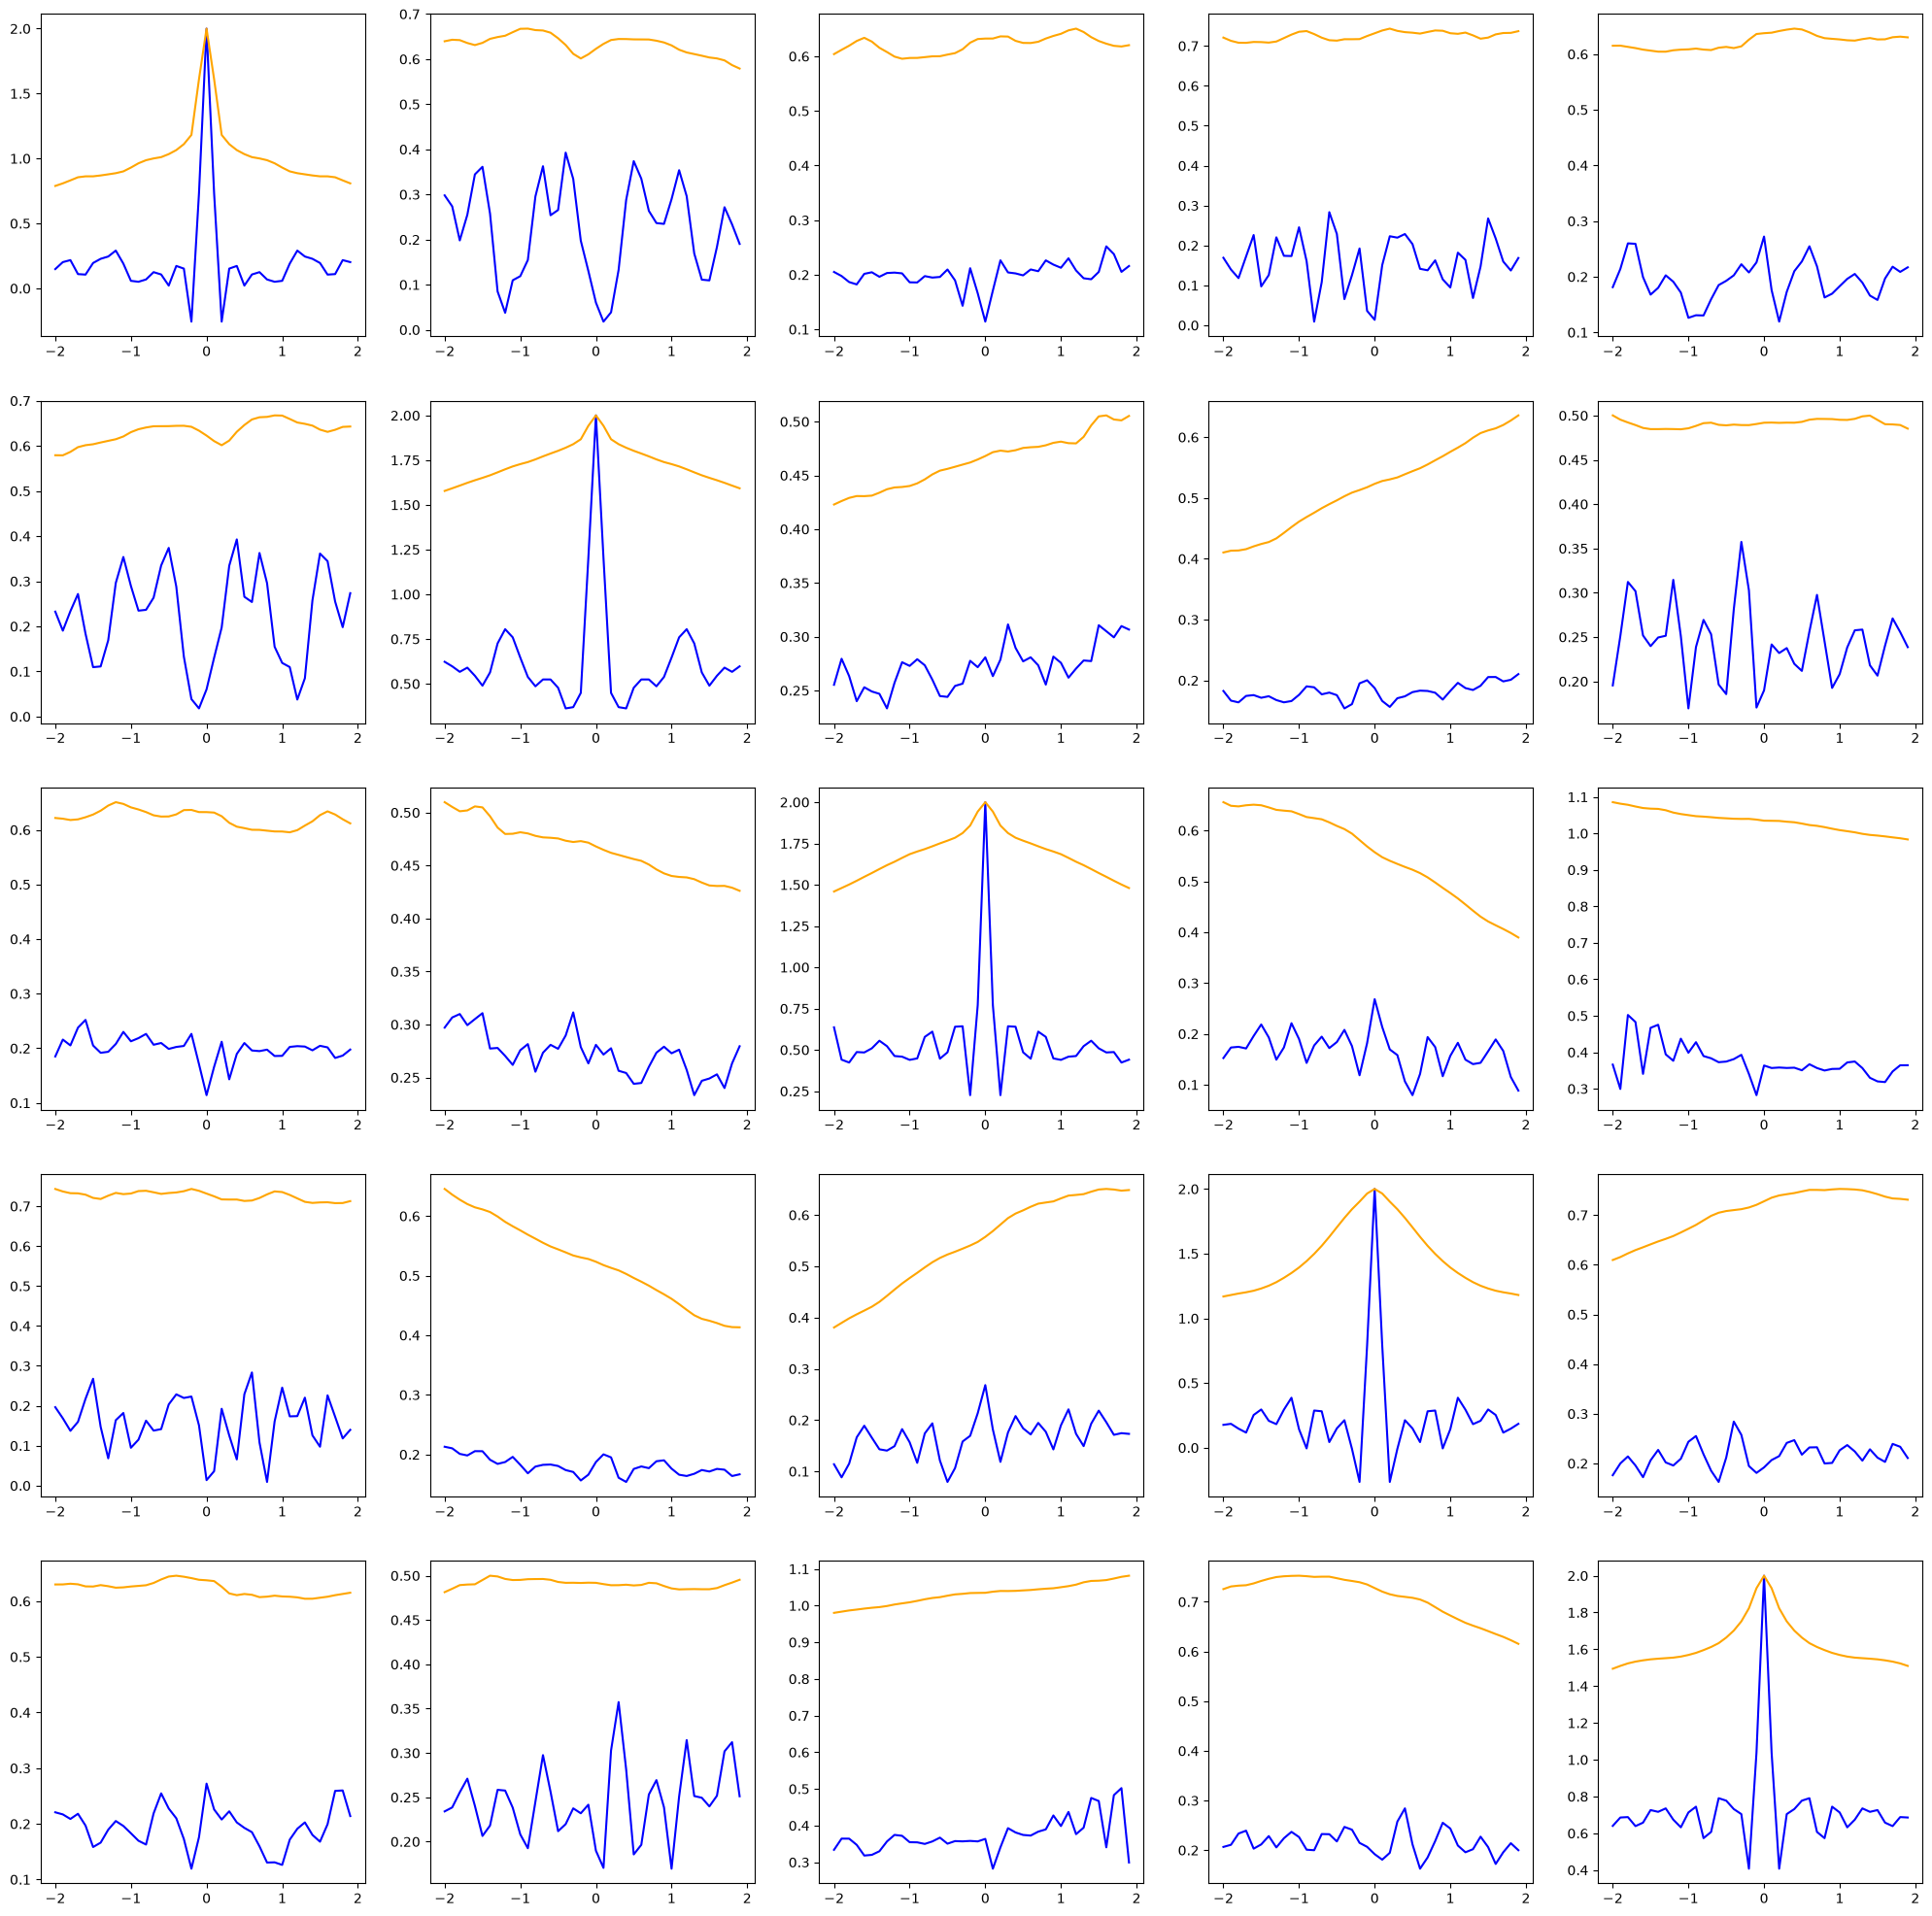

In [31]:
# plotting correlations
fig, ax = plt.subplots(5,5, figsize=(25, 25))
# flat_axes = ax.flatten()

# fig.delaxes(flat_axes[5])
tau = np.arange(-max_tm, max_tm, 1)

for i in range(no_of_fishes):
    for j in range(no_of_fishes):
        corr_val_raw = grand_C_raw[i, :, j]
        corr_val_clean = grand_C_clean[i, :, j]
        ax[i,j].plot(tau/10, corr_val_raw, color='blue')
        ax[i,j].plot(tau/10, corr_val_clean, color='orange')